# Baseline Model and Results for Faces Dataset

In this notebook, we implement a baseline convolutional neural network (CNN) model to classify images as either 'real' or 'fake' faces.

## Table of Contents
1. [Imports and Setup](#imports-and-setup)
2. [Data Preparation](#data-preparation)
3. [Model Building](#model-building)
4. [Model Training](#model-training)
5. [Model Evaluation](#model-evaluation)

### Imports and Setup

In [1]:
import sys
import os
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, f1_score, classification_report

### Data Preparation

In this section we mounted the data to colab, loaded and cleaned (from added computer files) the datasets. Lastly, we preprocessed the pixel range of the images to be in [0, 1].

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip /content/drive/MyDrive/dataset_train.zip -d /content/dataset_train/

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset_train/dataset_train/fake/SFHQ_pt4_00001695.jpg  
  inflating: /content/dataset_train/__MACOSX/dataset_train/fake/._SFHQ_pt4_00001695.jpg  
  inflating: /content/dataset_train/dataset_train/fake/ae76181bcc03c41b03e6399240ef1a4708992645.jpg  
  inflating: /content/dataset_train/__MACOSX/dataset_train/fake/._ae76181bcc03c41b03e6399240ef1a4708992645.jpg  
  inflating: /content/dataset_train/dataset_train/fake/53b0d7ec30f4b952e305b39f1241180ca2faca815bdde6df5359f2c4455770ed.jpg  
  inflating: /content/dataset_train/__MACOSX/dataset_train/fake/._53b0d7ec30f4b952e305b39f1241180ca2faca815bdde6df5359f2c4455770ed.jpg  
  inflating: /content/dataset_train/dataset_train/fake/SFHQ_pt3_00003280.jpg  
  inflating: /content/dataset_train/__MACOSX/dataset_train/fake/._SFHQ_pt3_00003280.jpg  
  inflating: /content/dataset_train/dataset_train/fake/SFHQ_pt2_00037256.jpg  
  inflating: /content/dataset_train/__MACOSX/dataset_t

In [4]:
!unzip /content/drive/MyDrive/dataset_test.zip -d /content/dataset_test/

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset_test/dataset_test/fake/c356c0f1955ff9158f2ea9cb3c0de27c633a19c8f36afed3f78390b2266a124c.jpg  
  inflating: /content/dataset_test/__MACOSX/dataset_test/fake/._c356c0f1955ff9158f2ea9cb3c0de27c633a19c8f36afed3f78390b2266a124c.jpg  
  inflating: /content/dataset_test/dataset_test/fake/SFHQ_pt3_00002129.jpg  
  inflating: /content/dataset_test/__MACOSX/dataset_test/fake/._SFHQ_pt3_00002129.jpg  
  inflating: /content/dataset_test/dataset_test/fake/852db75f71a850fb99d16967a9cd10e64651b64e60ede0bdf0e637c1342ec306.jpg  
  inflating: /content/dataset_test/__MACOSX/dataset_test/fake/._852db75f71a850fb99d16967a9cd10e64651b64e60ede0bdf0e637c1342ec306.jpg  
  inflating: /content/dataset_test/dataset_test/fake/SFHQ_pt4_00003753.jpg  
  inflating: /content/dataset_test/__MACOSX/dataset_test/fake/._SFHQ_pt4_00003753.jpg  
  inflating: /content/dataset_test/dataset_test/fake/149dd5622f8284690f9dcaa226b9fdf54f45e1f7b23e0d13

In [5]:
def load_image_dataset(data_path, batch_size=32, img_size=(200, 200), subset_ratio=1.0):
    """
    Load images from the specified directory.

    Expects structure:
       data_path/real/...
       data_path/fake/...

    Parameters:
        data_path (str): Path to dataset (e.g., "dataset_train" or "dataset_test").
        batch_size (int): Number of images per batch.
        img_size (tuple): Target image size.
        subset_ratio (float): Fraction of the dataset to use (default 1.0 = all).

    Returns:
        A tf.data.Dataset object ready for training/testing and the class names.
    """
    dataset = tf.keras.preprocessing.image_dataset_from_directory(
        data_path,
        labels='inferred',
        label_mode='binary',
        batch_size=batch_size,
        image_size=img_size,
        shuffle=True
    )
    class_names = dataset.class_names

    if subset_ratio < 1.0:
        total_batches = tf.data.experimental.cardinality(dataset).numpy()
        subset_batches = int(total_batches * subset_ratio)
        dataset = dataset.take(subset_batches)

    return dataset, class_names

In [6]:
import os
def clean_dataset(directory):
    allowed_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}

    for root, dirs, files in os.walk(directory):
        for file in files:
            ext = os.path.splitext(file)[-1].lower()
            if ext not in allowed_extensions:
                file_path = os.path.join(root, file)
                print(f"Deleting non-image file: {file_path}")
                os.remove(file_path)

# Clean train and test folders
clean_dataset("/content/dataset_train")
clean_dataset("/content/dataset_test")

Deleting non-image file: /content/dataset_train/__MACOSX/._dataset_train
Deleting non-image file: /content/dataset_train/__MACOSX/dataset_train/._.DS_Store
Deleting non-image file: /content/dataset_train/__MACOSX/dataset_train/._fake
Deleting non-image file: /content/dataset_train/__MACOSX/dataset_train/._real
Deleting non-image file: /content/dataset_train/dataset_train/.DS_Store
Deleting non-image file: /content/dataset_test/dataset_test/.DS_Store
Deleting non-image file: /content/dataset_test/__MACOSX/._dataset_test
Deleting non-image file: /content/dataset_test/__MACOSX/dataset_test/._.DS_Store
Deleting non-image file: /content/dataset_test/__MACOSX/dataset_test/._fake
Deleting non-image file: /content/dataset_test/__MACOSX/dataset_test/._real


In [7]:
!rm -r /content/dataset_test/__MACOSX
!rm -r /content/dataset_train/__MACOSX

In [8]:
def scale_images_to_unit_range(dataset):
    """
    Applies scaling to images in the dataset so that their pixel values are in the [0, 1] range.
    """
    def scaling_fn(image, label):
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    return dataset.map(scaling_fn)

### Model Building

In this section, we will build and train our model, plot its training history on both our training and validation data then test it on our test dataset to obtain the final accuracy results. We will finally look at the F1 score for our model to better understand its performance.

In [9]:
batch_size = 32
img_size = (200,200)
img_width, img_height = img_size

train_data_path = "/content/dataset_train/dataset_train"
test_data_path = "/content/dataset_test/dataset_test"

In [10]:
train_dataset, class_names = load_image_dataset(
    train_data_path, batch_size=batch_size, img_size=img_size, subset_ratio=1.0
)
train_dataset = scale_images_to_unit_range(train_dataset)

test_dataset, _ = load_image_dataset(
    test_data_path, batch_size=batch_size, img_size=img_size, subset_ratio=1.0
)
test_dataset = scale_images_to_unit_range(test_dataset)

train_count = tf.data.experimental.cardinality(train_dataset).numpy()
test_count = tf.data.experimental.cardinality(test_dataset).numpy()

print(f"Number of training batches: {train_count}")
print(f"Number of validation batches: {test_count}\n")

print(f"Approximate number of training images: {train_count * batch_size}")
print(f"Approximate number of validation images: {test_count * batch_size}")

print(f"Class names: {class_names}")

Found 96767 files belonging to 2 classes.
Found 24192 files belonging to 2 classes.
Number of training batches: 3024
Number of validation batches: 756

Approximate number of training images: 96768
Approximate number of validation images: 24192
Class names: ['fake', 'real']


We build a CNN.

In [19]:
model2 = models.Sequential([
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(img_size[0], img_size[1], 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model2.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 200, 200, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 100, 100, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 25, 25, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,605,441 (6.12 MB)

 Trainable params: 1,603,457 (6.12 MB)

 Non-trainable params: 1,984 (7.75 KB)

### Model Training

In [21]:
epochs = 8

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history2 = model2.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=epochs,
    callbacks=[early_stopping]
)

Epoch 1/8
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 202s 64ms/step - accuracy: 0.7538 - loss: 0.5060 - val_accuracy: 0.8076 - val_loss: 0.4437
Epoch 2/8
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 184s 61ms/step - accuracy: 0.8985 - loss: 0.2539 - val_accuracy: 0.7381 - val_loss: 0.7709
Epoch 3/8
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 201s 61ms/step - accuracy: 0.9419 - loss: 0.1569 - val_accuracy: 0.9423 - val_loss: 0.1569
Epoch 4/8
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 183s 60ms/step - accuracy: 0.9612 - loss: 0.1089 - val_accuracy: 0.7401 - val_loss: 0.9222
Epoch 5/8
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 183s 60ms/step - accuracy: 0.9713 - loss: 0.0781 - val_accuracy: 0.9362 - val_loss: 0.1925
Epoch 6/8
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 202s 61ms/step - accuracy: 0.9784 - loss: 0.0592 - val_accuracy: 0.9552 - val_loss: 0.1396
Epoch 7/8
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 208s 63ms/step - accuracy: 0.9835 - loss: 0.0458 - val_accuracy: 0.9580 - val_loss: 0.1274
Epoch 8/8
3024/3024 ━━━━━━━━━━━━━━━━━━━━ 195s 60ms/step - accuracy: 0.9865 -

We plot the training history of our CNN.

In [ ]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.plot(epochs_range, acc, 'b', label='Training accuracy')
    plt.plot(epochs_range, val_acc, 'r', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.figure()

    plt.plot(epochs_range, loss, 'b', label='Training loss')
    plt.plot(epochs_range, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

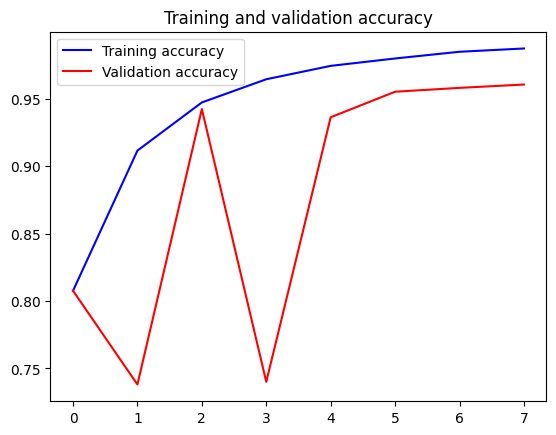

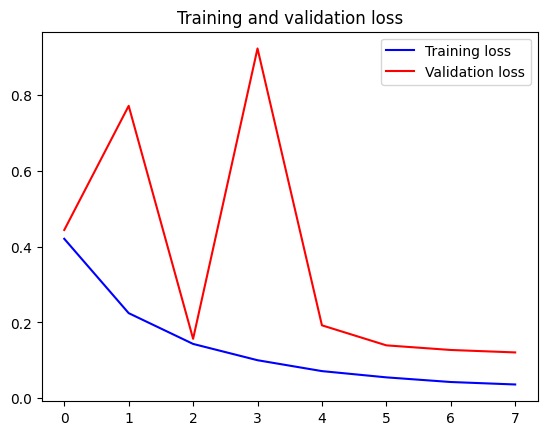

In [22]:
plot_history(history2)

### Model Evaluation

We test our CNN on our test data and observe its F1 score.

In [23]:
loss, accuracy = model2.evaluate(test_dataset)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

756/756 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9619 - loss: 0.1178
Test Loss: 0.1210, Test Accuracy: 0.9605


In [24]:
y_true = np.concatenate([y for x, y in test_dataset], axis=0)
y_pred_probs = model2.predict(test_dataset)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

cm = confusion_matrix(y_true, y_pred)

f1 = f1_score(y_true, y_pred)

print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

756/756 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step
Test Loss: 0.1210, Test Accuracy: 0.9605
Test F1 Score: 0.5719
Confusion Matrix:
[[4340 5852]
 [6050 7950]]

Classification Report:
              precision    recall  f1-score   support

        fake       0.42      0.43      0.42     10192
        real       0.58      0.57      0.57     14000

    accuracy                           0.51     24192
   macro avg       0.50      0.50      0.50     24192
weighted avg       0.51      0.51      0.51     24192

